### Behavioral Model Training (Synthetic)
This notebook trains the behavioral decision prediction model using the engineered synthetic dataset. The model learns rleationships between contextual factors such as scenario, difficulty, and emotional state to predict decision tendencies.

The training process includes data balancing and model optimization to improve classification performance. The trained model serves as the core decision-making component of the HDT system.

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
synthetic_features = np.load("../data/synthetic_features_scaled.npy")
synthetic_labels = np.load("../data/synthetic_labels_final.npy", allow_pickle = True)
print("Feature Shape")
print(synthetic_features.shape)
print("Label Shape")
print(synthetic_labels.shape)

Feature Shape
(3274, 36)
Label Shape
(3274,)


In [3]:
features_train, features_test, labels_train, labels_test = train_test_split(synthetic_features, synthetic_labels, test_size = 0.2, random_state = 42, stratify = synthetic_labels)
print("Training Feature Shape")
print(features_train.shape)
print("Testing Feature Shape")
print(features_test.shape)

Training Feature Shape
(2619, 36)
Testing Feature Shape
(655, 36)


In [4]:
behavior_prediction_model = HistGradientBoostingClassifier(max_iter = 300, learning_rate = 0.07, max_depth = 10, random_state = 42)
behavior_prediction_model.fit(features_train, labels_train)
print("Behavior Prediction Model Trained Successfuly")

Behavior Prediction Model Trained Successfuly


In [5]:
predicted_labels = behavior_prediction_model.predict(features_test)
model_accuracy = accuracy_score(labels_test, predicted_labels)
print("Model Accuracy")
print(model_accuracy)
print(classification_report(labels_test, predicted_labels))

Model Accuracy
0.8427480916030534
              precision    recall  f1-score   support

  analytical       0.55      0.33      0.42        33
    avoidant       0.88      0.87      0.88       202
    cautious       0.87      0.92      0.89       291
   impulsive       0.82      0.85      0.83       114
   proactive       0.00      0.00      0.00        15

    accuracy                           0.84       655
   macro avg       0.62      0.60      0.60       655
weighted avg       0.83      0.84      0.83       655



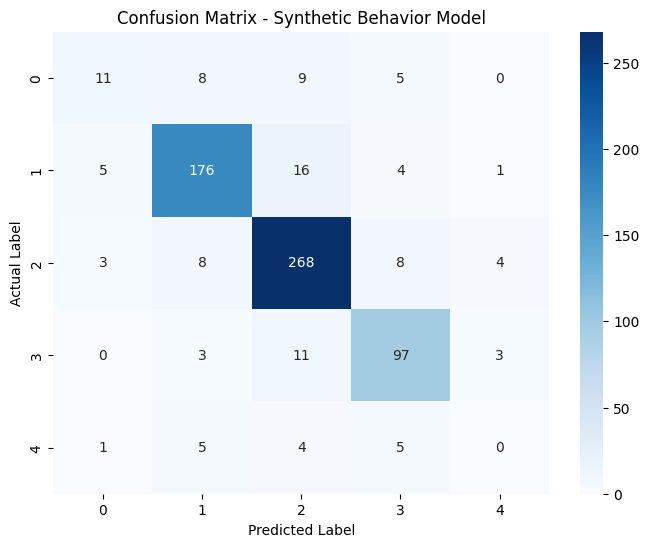

In [6]:
conf_matrix = confusion_matrix(labels_test, predicted_labels)
plt.figure(figsize = (8, 6))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Blues')
plt.title("Confusion Matrix - Synthetic Behavior Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [7]:
joblib.dump(behavior_prediction_model, "../models/synthetic_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully
